In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# PPO and KL: inspect the update and the measurement

Day 20 · Chapter 12. CPU, authored synthetic data, no downloads. Predict before each reference, change one declared variable, and interpret the result. Code is complete so the notebook runs from beginning to end. Completing its execution is material verification, not an assessment of learner mastery.

[Canonical chapter](../../book/chapters/12-language-generation-as-a-policy.md)


In [2]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / "src" / "dongxi_llms").is_dir():
    if root.parent == root:
        raise RuntimeError("Open this notebook within the Dongxi_LLMs repository")
    root = root.parent
sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
blue, orange, green = "#356a9b", "#b97139", "#3d8268"



## Exercise 1: the clipping direction

For positive advantage, which excessive movement stops earning benefit? What changes for negative advantage? Plot the actual clipped objective, then inspect its derivative.


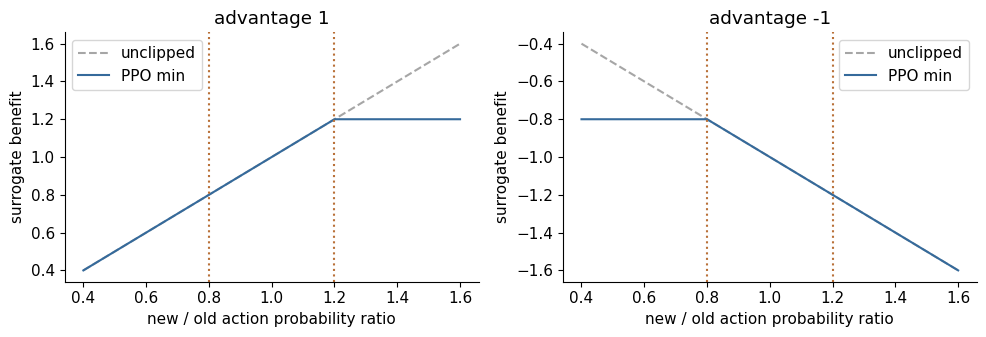

Slopes: [0.0, 1.0, -1.0, 0.0]


In [3]:
from dongxi_llms.policy_gradient_lab import ppo_surrogate,kl_estimators
ratio=torch.linspace(.4,1.6,241,dtype=torch.float64)
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for ax,a in zip(axes,(1.,-1.)):
    advantage=torch.full_like(ratio,a)
    ax.plot(ratio,ratio*advantage,color=".65",ls="--",label="unclipped")
    ax.plot(ratio,ppo_surrogate(ratio,advantage),color=blue,label="PPO min")
    ax.axvline(.8,color=orange,ls=":");ax.axvline(1.2,color=orange,ls=":")
    ax.set(xlabel="new / old action probability ratio",ylabel="surrogate benefit",title=f"advantage {a:g}");ax.legend()
plt.tight_layout();plt.show()
probe=torch.tensor([1.4,.6,1.4,.6],dtype=torch.float64,requires_grad=True)
adv=torch.tensor([1.,1.,-1.,-1.],dtype=torch.float64)
ppo_surrogate(probe,adv).sum().backward()
print("Slopes:",probe.grad.tolist())


![Saved reference plot for 02 ppo clipping and kl, figure 1](../figures/chapter-12/day-20-02_ppo_clipping_and_kl-01.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Solution:** clipping flattens already-favorable excessive changes; harmful changes remain penalized. It does not clip every ratio's gradient symmetrically and does not impose a global KL constraint.

## Exercise 2: KL estimator means and tails

Which estimator can be negative on one sample? Which nonnegative estimator is generally biased? All action probabilities are positive here.


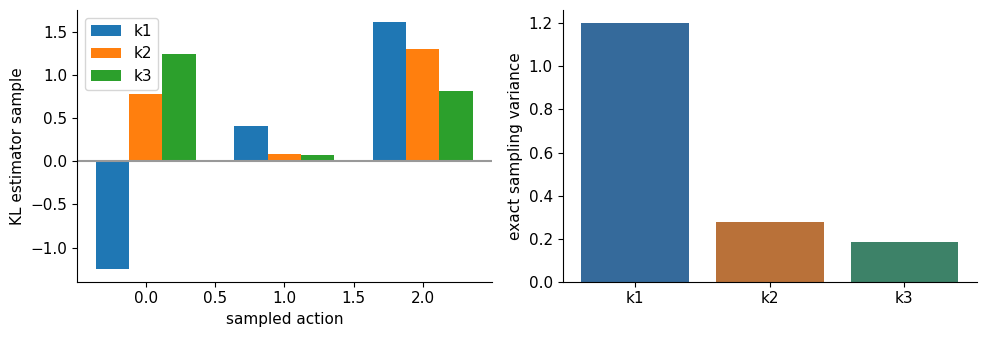

{'k1': {'mean': 0.6758058949504258, 'variance': 1.2016351865549857}, 'k2': {'mean': 0.8291743971023658, 'variance': 0.2763506407961554}, 'k3': {'mean': 0.6758058949504258, 'variance': 0.1835621998240384}}


In [4]:
p=torch.tensor([.2,.3,.5],dtype=torch.float64)
q=torch.tensor([.7,.2,.1],dtype=torch.float64)
results=kl_estimators(p,q)
torch.testing.assert_close(torch.tensor(results["k1"]["mean"]),torch.tensor(results["k3"]["mean"]))
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for offset,(name,r) in zip((-.24,0,.24),results.items()):
    axes[0].bar(torch.arange(3).numpy()+offset,r["samples"],width=.24,label=name)
axes[0].axhline(0,color=".6");axes[0].set(xlabel="sampled action",ylabel="KL estimator sample");axes[0].legend()
axes[1].bar(range(3),[r["variance"] for r in results.values()],color=[blue,orange,green])
axes[1].set_xticks(range(3),list(results));axes[1].set_ylabel("exact sampling variance")
plt.tight_layout();plt.show()
print({n:{k:v for k,v in r.items() if k!="samples"} for n,r in results.items()})


![Saved reference plot for 02 ppo clipping and kl, figure 2](../figures/chapter-12/day-20-02_ppo_clipping_and_kl-02.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Read the figure:** k1 has signed samples; k2 squares them and generally changes the expectation; k3 adds a zero-mean term under full common support. Its variance is measured here, not guaranteed lower for every pair of distributions.

## Exercise 3: rare support and sequence ratios

Make current-policy mass on action 0 tiny while reference mass stays large. Predict the k3 variance. Also compare token-ratio multiplication with a single token ratio.


In [5]:
rare_p=torch.tensor([1e-4,.3999,.6],dtype=torch.float64)
rare=kl_estimators(rare_p,q)
print("Rare-current-action estimator variances",{n:r["variance"] for n,r in rare.items()})
token_ratios=torch.tensor([1.1,1.1,1.1,1.1],dtype=torch.float64)
print({"one_token_ratio":float(token_ratios[0]),
       "trajectory_ratio":float(token_ratios.prod()),
       "sum_log_ratios":float(token_ratios.log().sum())})
try:kl_estimators(torch.tensor([0.,.4,.6]),q)
except ValueError as e:print("Support guard:",e)


Rare-current-action estimator variances {'k1': 0.3001712328392063, 'k2': 0.5926129782157046, 'k3': 4884.954722290053}
{'one_token_ratio': 1.1, 'trajectory_ratio': 1.4641000000000006, 'sum_log_ratios': 0.3812407192172998}
Support guard: Require matching strictly positive distributions


**Solution:** q/p can give k3 a large rare-event tail. Exact full-trajectory ratios multiply; PPO's token surrogate operates at states sampled by the old policy and is not the same correction. Missing current support breaks the k3 identity as stated. Sampling transformations and differentiable regularizer gradients need explicit contracts separate from these monitoring samples.
